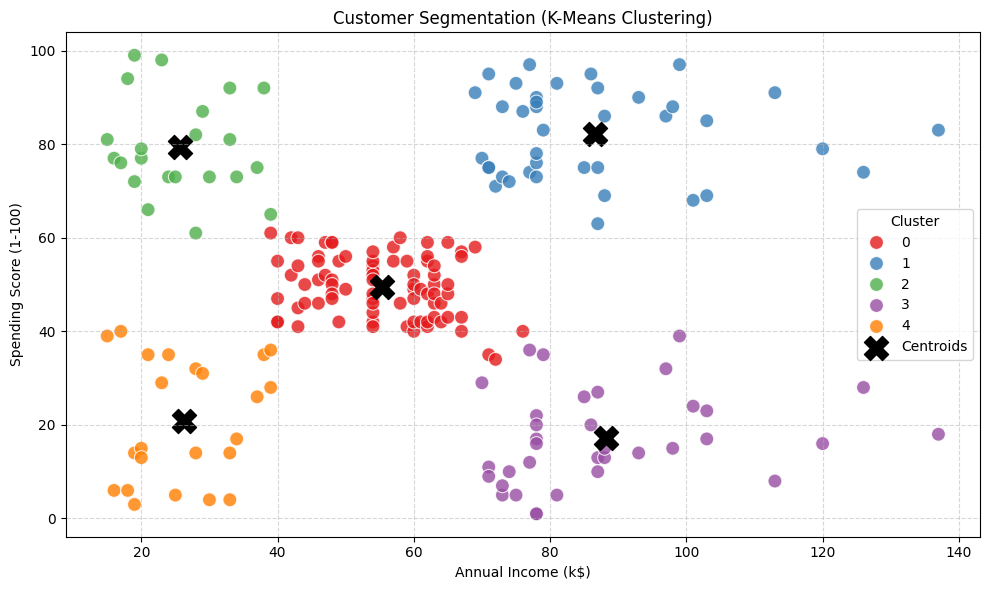

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Read the dataset directly from the raw GitHub URL
url = "https://raw.githubusercontent.com/majidramzi/clustering/refs/heads/main/mall-customer/mall_customers.csv"
df = pd.read_csv(url)

# Extract Annual Income and Spending Score for clustering
X = df.iloc[:, [3, 4]].values

# Scale the features so both variables carry equal weight
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means with 5 clusters
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# Visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y_kmeans, palette='Set1', s=100, alpha=0.8, legend='full')

# Plot the centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='black', marker='X', label='Centroids')

plt.title('Customer Segmentation (K-Means Clustering)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

The K-Means clustering algorithm was applied to the Mall Customers dataset, utilizing Annual Income and Spending Score. Feature scaling was performed prior to execution to ensure both variables contributed equally to the distance calculations. The algorithm successfully identified five distinct customer segments:

1. **High Income, High Spending (Target Audience)**: These customers earn the most and spend the most. They are prime targets for premium marketing campaigns and loyalty programs.
2. **High Income, Low Spending (Careful Spenders)**: This group has strong purchasing power but actively chooses not to spend it at the mall. Converting them requires highly targeted, value-driven promotions.
3. **Average Income, Average Spending (Standard Consumers)**: Positioned at the center of the plot, this is the largest cluster. They represent the baseline revenue stream and respond well to regular seasonal sales.
4. **Low Income, High Spending (Careless Spenders)**: Despite lower earnings, these individuals have high spending scores.
5. **Low Income, Low Spending (Sensible Spenders)**: This group operates on a tight budget and spends minimally.












